# Visualização de Campos Elétricos

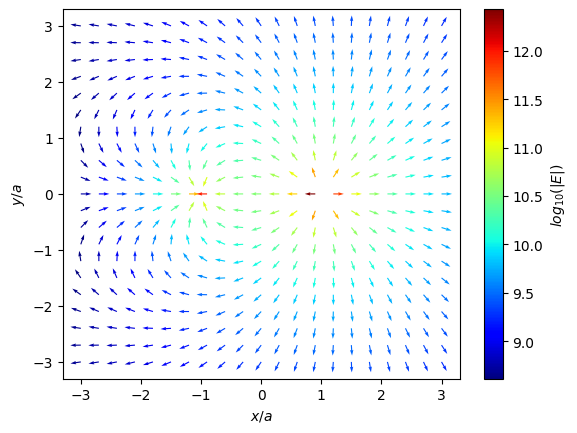

In [ ]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt


def E(r, q0, r0):
  """
  Calcula o campo elétrico E em um ponto r gerado por uma carga q0 localizada em r0.

  Parâmetros:
    r: vetor posição (array) onde se deseja calcular o campo
    q0: valor da carga elétrica (em Coulombs)
    r0: vetor posição da carga fonte

  Retorna:
    vetor campo elétrico E em r
  """
  R = r - r0  # vetor distância da carga ao ponto
  Rnorm = np.linalg.norm(R)  # módulo da distância
  E = q0 * R / (4 * np.pi * sc.epsilon_0 * Rnorm**3)  # Lei de Coulomb
  return E


# Gerar a grade de pontos no espaço 2D
a = 1e-3  # comprimento característico em metros (1 mm)
Lx, Ly = 3*a, 3*a  # limites do domínio nas direções x e y
Nx, Ny = 21, 21  # número de pontos na grade em cada eixo

x = np.linspace(-Lx, Lx, Nx)  # coordenadas x dos pontos
y = np.linspace(-Ly, Ly, Ny)  # coordenadas y dos pontos


# Criar matrizes de coordenadas (grade 2D) com indexação "ij" (linhas = x, colunas = y)
rx, ry = np.meshgrid(x, y, indexing = "ij")


# Calcular o campo elétrico
Ex = rx.copy()  # inicializa matriz da componente x do campo
Ey = ry.copy()  # inicializa matriz da componente y do campo


# Definir as cargas fonte
r1 = np.array([-a, 0])  # posição da carga 1
Q1 = -1.0e-6  # -1 micro Coulomb (carga negativa)
r2 = np.array([+a, 0])  # posição da carga 2
Q2 = +3.0e-6  # +1 micro Coulomb (carga positiva)


# Calcular o campo elétrico em cada ponto da grade
for i in range(Nx):
  for j in range(Ny):
    r = np.array([rx[i, j], ry[i, j]])  # vetor posição do ponto atual
    Ex[i, j], Ey[i, j] = E(r, Q1, r1) + E(r, Q2, r2)  # princípio da superposição


# Calcular a magnitude (módulo) do campo elétrico
Emag = np.sqrt(Ex**2 + Ey**2)


# Calcular os vetores unitários na direção do campo
nEx = Ex / Emag  # componente x do vetor unitário
nEy = Ey / Emag  # componente y do vetor unitário


# Visualizar o campo elétrico usando quiver plot
plt.quiver(rx/a, ry/a, nEx, nEy, np.log10(Emag), cmap = "jet")
plt.xlabel("$x/a$")  # eixo x normalizado por 'a'
plt.ylabel("$y/a$")  # eixo y normalizado por 'a'
plt.colorbar(label="$log_{10}(|E|)$")  # barra de cores com o logaritmo da magnitude
plt.show()  # exibe o gráfico (adicionado para completar a visualização)

# Referências

[1] Malthe-Sørenssen, A. (2015). *Elementary Electromagnetism Using Python: A Modern Course Combining Analytical and Numerical Techniques*. Editora Springer Cham.